In [83]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [84]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/r2000_a20'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/big_overview_10_10000p'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/big_overview_20_10000p'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/.DS_Store')]

In [85]:
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

In [86]:
#scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [87]:
vars_total = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation','g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0','jackson_root_beta']

In [88]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.1]
index_to_drop = df[(df['sid'] == 2) | (df['sid'] == 2)].index
df.drop(index_to_drop, inplace=True)
df_mean = df.groupby(['id'])[vars_total].mean()


In [89]:
def round_sigfig(num, sig_figs):
    """Rounds a number to a specified number of significant figures.

    Args:
        num: The number to round.
        sig_figs: The number of significant figures.

    Returns:
        The rounded number.
    """

    if num == 0:
        return 0
    else:
        return round(num, sig_figs - int(np.floor(np.log10(abs(num)))) - 1)
    

In [90]:
vars_plant

['stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'g0',
 'jackson_root_beta']

In [91]:
vars_sel = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'psi50_xylem' ,'g0','jackson_root_beta']
vars_sel_name = [  r"$\Gamma_\mathrm{Stem}$",r"$k_\mathrm{xyl}$",r"Huber", r'$\Psi_{50}$', r"$g_0$",r"$\mathrm{Root}_\beta$"]

In [92]:
vars_sel
units = ["mol m-3 MPa-1", "mol m-1 s-1 MPa-1", "-", "MPa", "mol m-1 s-1", "-"]

stem_hydraulic_capacitance
k_xylem_sat
huber_value
psi50_xylem
g0
jackson_root_beta


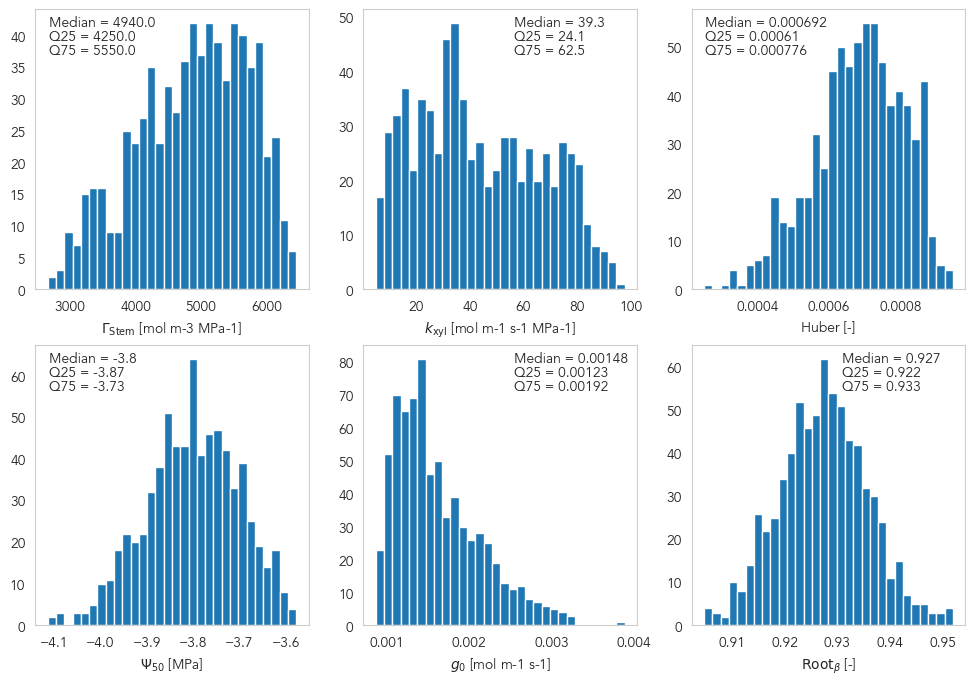

In [97]:
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize=(12, 8))
i =1 
for var, unit in zip(vars_sel,units):
    ax = fig.add_subplot(2, 3, i)
    ax.hist(df_mean[var], alpha=1.0, bins=30);
    ax.set_xlabel(f"{var} [{unit}]")
    if (i < 5 ) & (i!=2):
        ax.text(0.05,0.94,f"Median = {round_sigfig(df_mean[var].median(),3)}", transform=ax.transAxes);
        ax.text(0.05,0.89,f"Q25 = {round_sigfig(df_mean[var].quantile(q = 0.25),3)}", transform=ax.transAxes);
        ax.text(0.05,0.84,f"Q75 = {round_sigfig(df_mean[var].quantile(q = 0.75),3)}", transform=ax.transAxes);
    else:
        ax.text(0.55,0.94,f"Median = {round_sigfig(df_mean[var].median(),3)}", transform=ax.transAxes);
        ax.text(0.55,0.89,f"Q25 = {round_sigfig(df_mean[var].quantile(q = 0.25),3)}", transform=ax.transAxes);
        ax.text(0.55,0.84,f"Q75 = {round_sigfig(df_mean[var].quantile(q = 0.75),3)}", transform=ax.transAxes);
    ax.grid(False)
    ax.set_xlabel(f"{vars_sel_name[i-1]} [{units[i-1]}]")
    i+=1
    print(var)

plt.savefig(f"{post_path}/figure3_selective_variables.png", bbox_inches='tight', dpi = 300)
plt.show()
# plt.close(fig)


In [98]:
df_mean['bins_kapp'] =pd.cut(df_mean[vars_sel[0]], bins = [0,3000,4000,5000,6000,7000])

(array([18., 16.,  9.,  6.,  3.,  0.,  0.,  0.,  0.]),
 array([6000., 6100., 6200., 6300., 6400., 6500., 6600., 6700., 6800.,
        6900.]),
 <BarContainer object of 9 artists>)

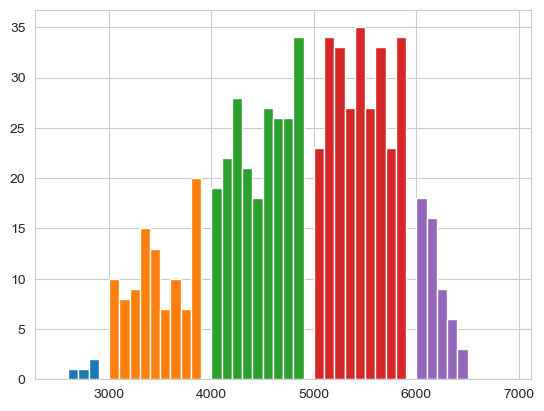

In [39]:
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=0, right=3000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(2500,3000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(3000,4000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(4000,5000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(5000,6000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(6000,7000,100))

/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[          nan,           nan,           nan,           nan,
                   nan,           nan,           nan],
        [1738.0952381 ,  666.66666667,   95.23809524,    0.        ,
            0.        ,    0.        ,    0.        ],
        [1069.95884774,  936.21399177,  370.37037037,  113.16872428,
           10.28806584,    0.        ,    0.        ],
        [ 598.95833333,  668.40277778,  607.63888889,  373.26388889,
          199.65277778,   52.08333333,    0.        ],
        [ 153.06122449,  561.2244898 ,  765.30612245,  459.18367347,
          306.12244898,  255.10204082,    0.        ]]),
 array([0.001 , 0.0014, 0.0018, 0.0022, 0.0026, 0.003 , 0.0034, 0.0038]),
 <a list of 5 BarContainer objects>)

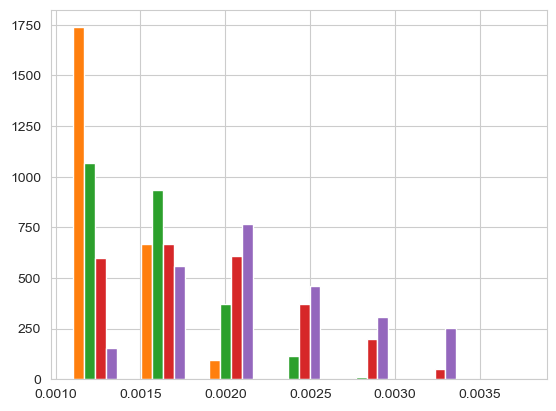

In [73]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['g0'].values,
          dh2['g0'].values,
          dh3['g0'].values,
          dh4['g0'].values,
          dh5['g0'].values],
         bins=np.arange(0.001, 0.004,0.0004
                        ), histtype='bar', density=True)


/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[          nan,           nan,           nan,           nan,
                   nan,           nan,           nan,           nan,
                   nan],
        [   0.        ,    0.        ,  169.49152542,  423.72881356,
         2796.61016949, 3305.08474576, 3220.33898305,   84.74576271,
            0.        ],
        [   0.        ,    0.        ,  433.07086614, 1574.80314961,
         3346.45669291, 2834.64566929, 1653.54330709,  157.48031496,
            0.        ],
        [   0.        ,  341.29692833, 1228.66894198, 1569.96587031,
         2593.85665529, 2354.94880546, 1774.7440273 ,  136.51877133,
            0.        ],
        [ 192.30769231,  769.23076923,  769.23076923, 1538.46153846,
         3076.92307692, 2500.        , 1153.84615385,    0.        ,
            0.        ]]),
 array([0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009,
        0.001 , 0.0011]),
 <a list of 5 BarContainer objects>)

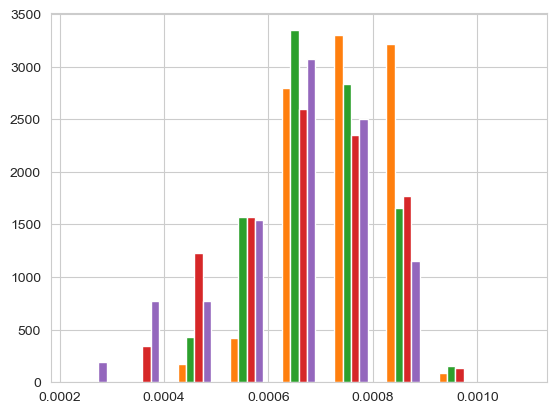

In [68]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['huber_value'].values,
          dh2['huber_value'].values,
          dh3['huber_value'].values,
          dh4['huber_value'].values,
          dh5['huber_value'].values],
         bins=np.arange(0.0002, 0.0012,0.0001), histtype='bar', density=True)

/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[       nan,        nan,        nan,        nan,        nan,
                nan,        nan],
        [0.        , 0.16949153, 1.69491525, 2.88135593, 3.55932203,
         1.61016949, 0.08474576],
        [0.03937008, 0.23622047, 1.25984252, 3.1496063 , 3.50393701,
         1.73228346, 0.07874016],
        [0.        , 0.20477816, 1.39931741, 3.37883959, 3.3447099 ,
         1.53583618, 0.13651877],
        [0.        , 0.57692308, 0.96153846, 4.61538462, 2.88461538,
         0.96153846, 0.        ]]),
 array([-4.2, -4.1, -4. , -3.9, -3.8, -3.7, -3.6, -3.5]),
 <a list of 5 BarContainer objects>)

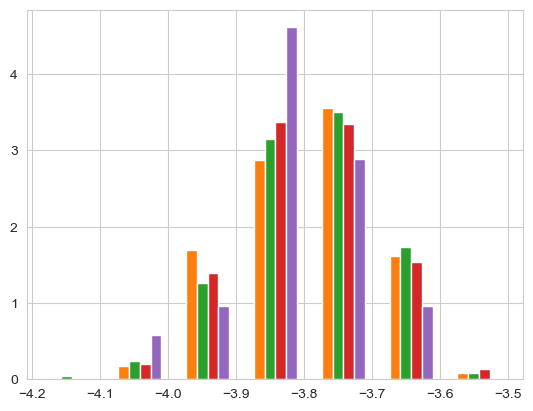

In [76]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['psi50_xylem'].values,
          dh2['psi50_xylem'].values,
          dh3['psi50_xylem'].values,
          dh4['psi50_xylem'].values,
          dh5['psi50_xylem'].values],
         bins=np.arange(-4.2,-3.5, 0.1), histtype='bar', density=True)

/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[       nan,        nan,        nan,        nan,        nan,
                nan],
        [0.01299435, 0.01977401, 0.00960452, 0.01186441, 0.00847458,
         0.0039548 ],
        [0.01554677, 0.01633729, 0.01080369, 0.01080369, 0.01027668,
         0.00289855],
        [0.00958904, 0.0152968 , 0.0130137 , 0.01255708, 0.01164384,
         0.00456621],
        [0.00641026, 0.01794872, 0.01025641, 0.00897436, 0.01666667,
         0.00641026]]),
 array([ 5., 20., 35., 50., 65., 80., 95.]),
 <a list of 5 BarContainer objects>)

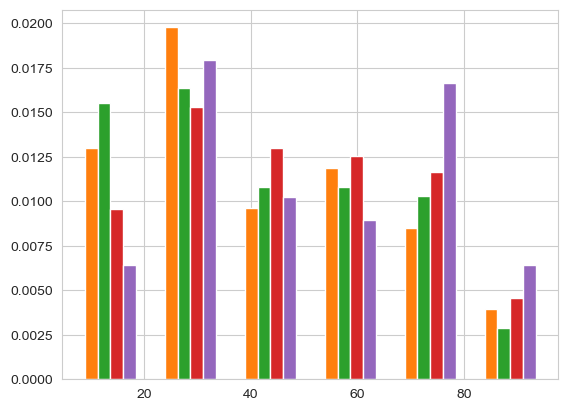

In [82]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['k_xylem_sat'].values,
          dh2['k_xylem_sat'].values,
          dh3['k_xylem_sat'].values,
          dh4['k_xylem_sat'].values,
          dh5['k_xylem_sat'].values],
         bins=np.arange(5,100, 15), histtype='bar', density=True)

stem_hydraulic_capacitance
k_xylem_sat
huber_value
psi50_xylem
g0
jackson_root_beta
g_bark


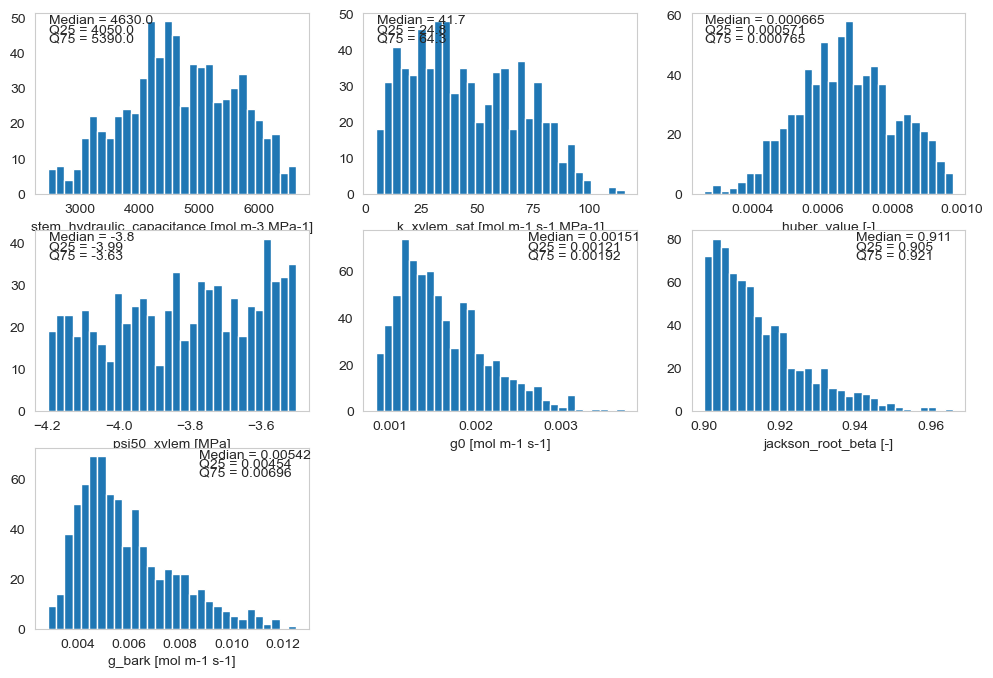

In [34]:
df_mean_1= df[df['sid'] == 4]
fig = plt.figure(figsize=(12, 8))
i = 1 
for var, unit in zip(vars_sel,units):
    ax = fig.add_subplot(3, 3, i)
    ax.hist(df_mean_1[var], alpha=1.0, bins=30);
    ax.set_xlabel(f"{var} [{unit}]")
    if i < 5:
        ax.text(0.05,0.94,f"Median = {round_sigfig(df_mean_1[var].median(),3)}", transform=ax.transAxes);
        ax.text(0.05,0.89,f"Q25 = {round_sigfig(df_mean_1[var].quantile(q = 0.25),3)}", transform=ax.transAxes);
        ax.text(0.05,0.84,f"Q75 = {round_sigfig(df_mean_1[var].quantile(q = 0.75),3)}", transform=ax.transAxes);
    else:
        ax.text(0.6,0.94,f"Median = {round_sigfig(df_mean_1[var].median(),3)}", transform=ax.transAxes);
        ax.text(0.6,0.89,f"Q25 = {round_sigfig(df_mean_1[var].quantile(q = 0.25),3)}", transform=ax.transAxes);
        ax.text(0.6,0.84,f"Q75 = {round_sigfig(df_mean_1[var].quantile(q = 0.75),3)}", transform=ax.transAxes);
    ax.grid(False)
    i+=1
    print(var)

plt.savefig(f"{post_path}/figure3_selective_variables_dead_1.png", bbox_inches='tight', dpi = 300)
plt.show()

In [ ]:
df_mean_1= df[df['sid'] == 1]